# Lab 3 Practical: Image Captioning 
This notebook implements an end-to-end image captioning system using ResNet-50 for image encoding and LSTM for caption generation.

## Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
!pip install nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
import os
import numpy as np
from collections import Counter
from nltk.tokenize import word_tokenize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Define Dataset Class
We define a custom Dataset class that:

- Loads images and captions from a CSV-style .txt file (filename,caption format)
- Filters only images that actually exist
- Tokenises captions using NLTK and builds a vocabulary
- Converts each caption into a sequence of indices

Token	Meaning
- PAD	Padding token for aligning caption lengths within a batch.
- START Marks the beginning of a caption. Helps the decoder know when to start.
- END	Marks the end of a caption. Tells the decoder when to stop generating.
- UNK	“Unknown” token for rare or unseen words not in the vocabulary.

In [2]:
# Define Dataset Class (Captions from CSV)
class SimpleImageCaptionDataset(Dataset):
    def __init__(self, image_folder, caption_file, transform=None):
        self.image_folder = image_folder
        self.transform = transform
        self.captions = {}

        # Only load captions where the image file actually exists
        with open(caption_file, 'r') as f:
            for line in f:
                if ',' in line:
                    img, caption = line.strip().split(',', 1)
                    img_path = os.path.join(self.image_folder, img)
                    if os.path.exists(img_path) and img not in self.captions:
                        self.captions[img] = caption

        # Build vocabulary from filtered captions
        self.word_freq = Counter()
        for cap in self.captions.values():
            self.word_freq.update(word_tokenize(cap.lower()))

        self.special_tokens = ['<PAD>', '<START>', '<END>', '<UNK>']
        self.vocab = self.special_tokens + [w for w in self.word_freq if self.word_freq[w] > 1]
        self.word2idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        img_name = list(self.captions.keys())[idx]
        caption = self.captions[img_name].lower()
        image = Image.open(os.path.join(self.image_folder, img_name)).convert('RGB')
        if self.transform:
            image = self.transform(image)
        tokens = ['<START>'] + word_tokenize(caption) + ['<END>']
        caption_idx = [self.word2idx.get(t, self.word2idx['<UNK>']) for t in tokens]
        return image, torch.tensor(caption_idx)
    

## CNN Encoder
We use a pre-trained ResNet-50 model to extract visual features from images.
We remove the final classification layer and freeze all weights since we only use it as a feature extractor.

In [18]:
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = torchvision.models.resnet18(pretrained=True)
        modules = list(self.cnn.children())[:-2]  # keep up to second-last conv layer
        self.features = nn.Sequential(*modules)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # flatten to [B, C, 1, 1]
        self.fc = nn.Linear(C, embed_size)        # map to embedding size

    def forward(self, images):
        x = self.features(images)     # [B, C, H, W]
        x = self.pool(x)              # [B, C, 1, 1]
        x = x.view(x.size(0), -1)     # [B, C]
        x = self.fc(x)                # [B, E]
        return x

## LSTM Decoder
The decoder is an LSTM-based sequence model that generates captions one word at a time.
It takes:

1. An initial hidden state derived from the image
2. An embedded version of the caption input (e.g., "<START> the dog")
3. Outputs a probability distribution over the vocabulary for each time step

init_h / init_c	Linear layers that map image features to LSTM’s initial hidden and cell states.

In [4]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.linear_feat = nn.Linear(2048, embed_size)  # project image to same size as embedding
        self.lstm = nn.LSTM(embed_size * 2, hidden_size, batch_first=True)  # doubled input size
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        batch_size = captions.size(0)
        seq_len = captions.size(1) - 1  # ignore <END>

        # Word embeddings: [B, T-1, E]
        embeddings = self.embed(captions[:, :-1])

        # Image features: [B, 2048] → [B, E]
        image_embed = self.linear_feat(features)

        # Expand image embedding to all time steps: [B, E] → [B, T-1, E]
        image_embed_expanded = image_embed.unsqueeze(1).expand(-1, seq_len, -1)

        # Concatenate word embeddings + image embedding: [B, T-1, 2E]
        combined_input = torch.cat((embeddings, image_embed_expanded), dim=2)

        out, _ = self.lstm(combined_input)
        return self.linear(out)

## Load Dataset & DataLoader
Define preprocessing transformations (resize, normalise), then load the dataset using our earlier class. We also set up the DataLoader to batch images and captions for training.

In [14]:
# Define the transform 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create the dataset
dataset = SimpleImageCaptionDataset(
    image_folder='Images',
    caption_file='captions.txt',
    transform=transform
)

# Define the split sizes
train_size = int(0.8 * len(dataset))  # 80% for training
val_size = len(dataset) - train_size  # 20% for validation/test

# Split the dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 2 dataloader for train and test
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda batch: (
    torch.stack([b[0] for b in batch]),
    nn.utils.rnn.pad_sequence([b[1] for b in batch], batch_first=True, padding_value=dataset.word2idx['<PAD>'])
))

val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=lambda batch: (
    torch.stack([b[0] for b in batch]),
    nn.utils.rnn.pad_sequence([b[1] for b in batch], batch_first=True, padding_value=dataset.word2idx['<PAD>'])
))


## Training
We train the decoder using cross-entropy loss while keeping the encoder frozen, using only the training set.
For each batch:
1. We encode the image
2. Feed it into the decoder along with the caption
3. Compute the loss between predicted and actual caption
4. Update the decoder weights


*loss.backward()*	Computes gradients for all learnable parameters in the decoder.  
*optimizer.step()*	Applies the gradients to update model weights.  
*criterion*	The loss function, measuring how far off the predictions are.

In [10]:
# Training Loop 

encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(dataset.vocab)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=dataset.word2idx['<PAD>'])
optimizer = optim.Adam(decoder.parameters(), lr=0.001)

encoder.eval()  # keep encoder frozen
decoder.train()

num_epochs = 50

for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (images, captions) in enumerate(train_loader):
        images, captions = images.to(device), captions.to(device)
        features = encoder(images)
        outputs = decoder(features, captions)
        targets = captions[:, 1:]  # Shift target by 1
    
        loss = criterion(outputs.view(-1, outputs.size(-1)), targets.reshape(-1))
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)  
    print(f"Epoch {epoch+1} completed. Average loss: {avg_loss: .4f}")


Batch 0, Loss: 6.5493
Batch 10, Loss: 4.5975
Batch 20, Loss: 4.1199
Batch 30, Loss: 4.7060
Batch 40, Loss: 4.6413
Batch 50, Loss: 4.4214
Batch 60, Loss: 4.4870
Batch 70, Loss: 4.4519
Batch 80, Loss: 4.0226
Batch 90, Loss: 3.7198
Batch 100, Loss: 4.1973
Batch 110, Loss: 4.6345
Batch 120, Loss: 4.6379
Batch 130, Loss: 3.6178
Batch 140, Loss: 4.1716
Batch 150, Loss: 4.0543
Batch 160, Loss: 2.9131
Batch 170, Loss: 4.1883
Batch 180, Loss: 3.6215
Batch 190, Loss: 3.7237
Batch 200, Loss: 3.5972
Batch 210, Loss: 3.7286
Batch 220, Loss: 3.7553
Batch 230, Loss: 2.9514
Batch 240, Loss: 4.4124
Batch 250, Loss: 4.6832
Batch 260, Loss: 3.8914
Batch 270, Loss: 4.1320
Batch 280, Loss: 3.7880
Batch 290, Loss: 3.4973
Batch 300, Loss: 4.1770
Batch 310, Loss: 3.8388
Batch 320, Loss: 3.6726
Batch 330, Loss: 3.8378
Batch 340, Loss: 3.1636
Batch 350, Loss: 3.8351
Batch 360, Loss: 3.2738
Batch 370, Loss: 3.2584
Batch 380, Loss: 1.8925
Batch 390, Loss: 3.5690
Epoch 1 completed. Average loss:  3.9344
Batch 0, L

## Greedy Caption Generation with Concatenation
This function generates a caption using greedy decoding with feature-level concatenation of image and word embeddings:
1. The image is encoded into a fixed-size feature vector using a CNN encoder.
2. At each time step:
   - The current input word is embedded into a vector.
   - This word embedding is concatenated with the image embedding, creating a combined input that fuses visual and textual information.  
   - The combined vector is fed into an LSTM to predict the next word.  
3. The model selects the word with the highest probability (greedy decoding).
4. The process continues, using each predicted word as the next input, until:  
    - the <END> token is generated, or  
    - the maximum caption length is reached.

- _encoder(image.unsqueeze(0))_	Image Encoding:	Adds a batch dimension to the image (from [C, H, W] → [1, C, H, W]). The encoder turns the image into a fixed-size feature vector.  
- _decoder.linear_feat(feature)_	Feature Projection:	Projects image features (e.g., [1, 2048]) into the same embedding space ([1, E]) used for word vectors. Enables concatenation with word embeddings. 
- _decoder.embed(inputs)_	Word Embedding:	Converts the current input word index into a dense vector ([1, 1, E]), representing semantic meaning in continuous space.  
- _img_exp = image_embed.unsqueeze(1)_	Dimension Matching:	Expands the image embedding to match the word embedding’s sequence dimension — both need shape [1, 1, E] to concatenate.  
- _torch.cat((word_emb, img_exp), dim=2)_	Concatenation:	Joins the word and image embeddings along the last dimension to form [1, 1, 2E]. This fuses visual and textual context.  
- _decoder.lstm(...)_	LSTM Decoding:	A recurrent neural network processes the combined input and maintains internal memory (h, c) to generate coherent sequences.  
- _output = decoder.linear(out.squeeze(1))_	Vocabulary Projection:	Maps LSTM output to vocabulary space — each score corresponds to a word in the vocabulary.  
- _predicted = output.argmax(1)_	Next Word Prediction:	Selects the word with the highest score (most likely) to be the next word in the caption.  
- _inputs = predicted.view(1, 1)_	Autoregressive Looping:	The predicted word is reshaped and used as the next input, continuing the caption generation one word at a time.  

In [23]:
def generate_caption_concat(encoder, decoder, image, word2idx, idx2word, max_length=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        # Encode image → [1, 2048]
        feature = encoder(image.unsqueeze(0).to(device))  # [1, 2048]
        image_embed = decoder.linear_feat(feature)        # [1, E]

        inputs = torch.tensor([[word2idx['<START>']]]).to(device)
        caption = []

        h, c = None, None

        for _ in range(max_length):
            # Embed current word: [1, 1, E]
            word_emb = decoder.embed(inputs)
            word_emb = word_emb.view(word_emb.size(0), word_emb.size(1), -1)  # Ensure correct shape

            # Expand image embedding: [1, E] → [1, 1, E]
            img_exp = image_embed.unsqueeze(1)

            # Concatenate: [1, 1, 2E]
            lstm_input = torch.cat((word_emb, img_exp), dim=2)

            # LSTM forward
            out, (h, c) = decoder.lstm(lstm_input, (h, c)) if h is not None else decoder.lstm(lstm_input)

            # Generate next word
            output = decoder.linear(out.squeeze(1))
            predicted = output.argmax(1)
            word = idx2word[predicted.item()]

            if word == '<END>':
                break
            caption.append(word)

            inputs = predicted.view(1, 1)  # Prepare input for next step

    return ' '.join(caption)


## Visual Comparison – Ground Truth vs Generated
We select a few images and show:
- The ground truth caption
- The generated caption

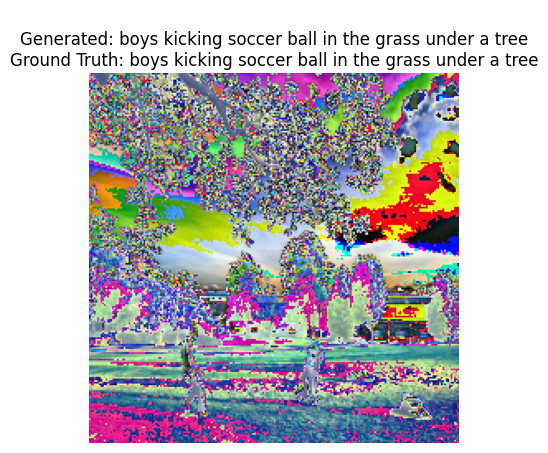

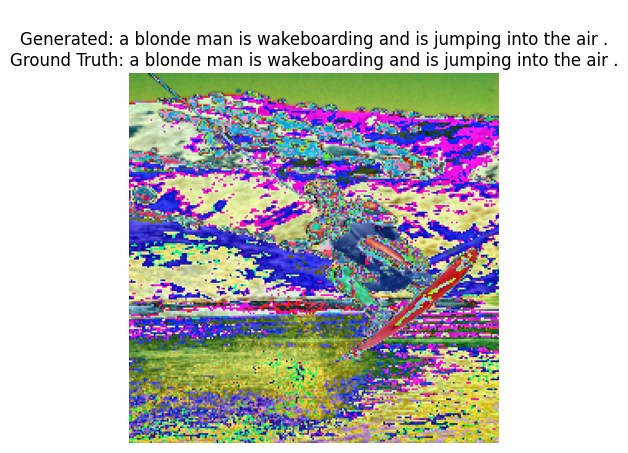

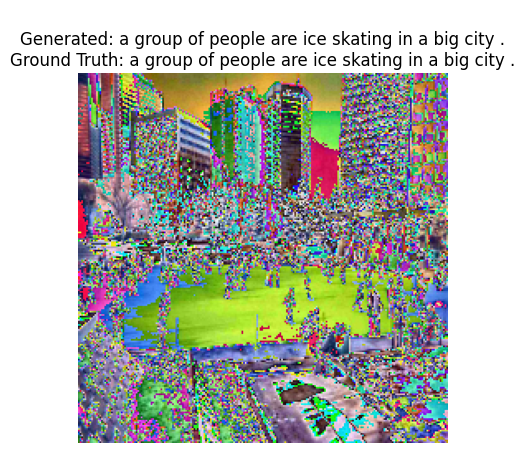

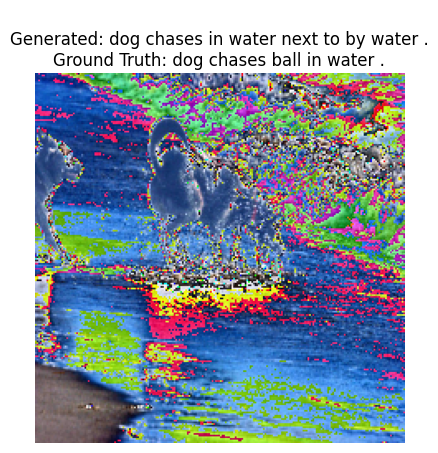

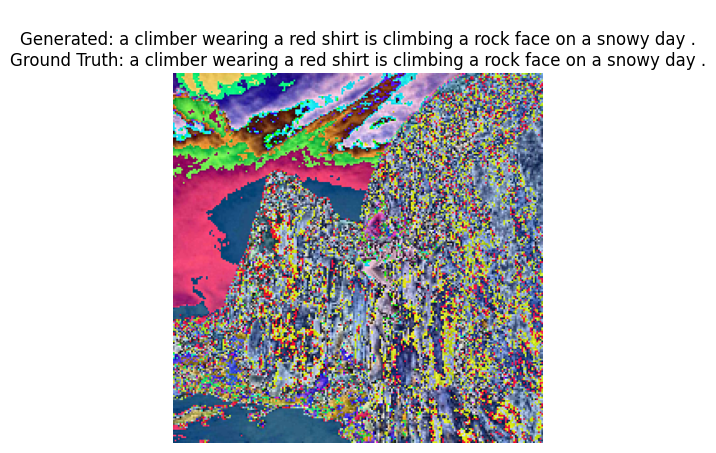

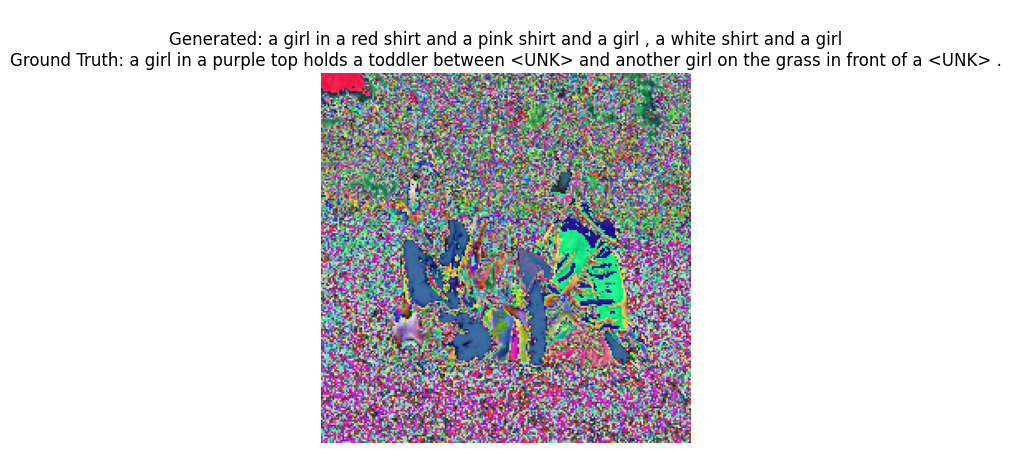

In [25]:
# Display Ground Truth vs Generated Captions

import matplotlib.pyplot as plt

encoder.eval()
decoder.eval()

for i in range(6):  # show 6 examples
    image, caption_tensor = val_dataset[i]
    image = image.to(device)
    
    true_caption = ' '.join([
        dataset.idx2word[idx.item()]
        for idx in caption_tensor
        if idx.item() not in [
            dataset.word2idx['<PAD>'],
            dataset.word2idx['<START>'],
            dataset.word2idx['<END>']
        ]
    ])
    generated_caption = generate_caption_concat(encoder, decoder, image, dataset.word2idx, dataset.idx2word)

    plt.imshow(transforms.ToPILImage()(image))
    plt.axis('off')
    plt.title(f"\nGenerated: {generated_caption}\nGround Truth: {true_caption}")
    plt.show()


## BLEU Score Evaluation
This measures the similarity between the generated caption and the ground truth using BLEU which is a common metric in NLP.
We use smoothing to avoid issues with short captions.

In [26]:
# BLEU Score Evaluation

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

encoder.eval()
decoder.eval()

smoothie = SmoothingFunction().method4

for i in range(6):  # evaluate 3 examples
    image, caption_tensor = val_dataset[i]
    image = image.to(device)

    # Ground truth
    reference = [
        dataset.idx2word[idx.item()]
        for idx in caption_tensor
        if idx.item() not in [
            dataset.word2idx['<PAD>'],
            dataset.word2idx['<START>'],
            dataset.word2idx['<END>']
        ]
    ]

    # Prediction
    candidate = generate_caption_concat(encoder, decoder, image, dataset.word2idx, dataset.idx2word).split()

    # Compute BLEU
    bleu = sentence_bleu([reference], candidate, smoothing_function=smoothie)

    print(f"Sample {i + 1} BLEU score: {bleu:.4f}")
    print(f"Reference: {' '.join(reference)}")
    print(f"Generated: {' '.join(candidate)}\n")


Sample 1 BLEU score: 1.0000
Reference: boys kicking soccer ball in the grass under a tree
Generated: boys kicking soccer ball in the grass under a tree

Sample 2 BLEU score: 1.0000
Reference: a blonde man is wakeboarding and is jumping into the air .
Generated: a blonde man is wakeboarding and is jumping into the air .

Sample 3 BLEU score: 1.0000
Reference: a group of people are ice skating in a big city .
Generated: a group of people are ice skating in a big city .

Sample 4 BLEU score: 0.1046
Reference: dog chases ball in water .
Generated: dog chases in water next to by water .

Sample 5 BLEU score: 1.0000
Reference: a climber wearing a red shirt is climbing a rock face on a snowy day .
Generated: a climber wearing a red shirt is climbing a rock face on a snowy day .

Sample 6 BLEU score: 0.1227
Reference: a girl in a purple top holds a toddler between <UNK> and another girl on the grass in front of a <UNK> .
Generated: a girl in a red shirt and a pink shirt and a girl , a white sh